In [58]:
# Importamos librerias a utilizar
from scipy.io import arff
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.pipeline import Pipeline
from Preprocessing import DataPreProcessor, TargetEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [59]:
#Cargamos el dataset y lo transformamos en un DataFrame de pandas para poder manipularlo de manera más sencilla.

data, meta = arff.loadarff("/Users/Camila/Desktop/datasets/dataset_31_credit-g.arff")
df = pd.DataFrame(data)

#Decodificamos los strings que provienen del archivo ARFF para que sean legibles y consistentes en el DataFrame.
for column in df.select_dtypes([object]).columns:
    df[column] = df[column].str.decode('utf-8')

#Transformamos el tipo de dato objeto a categorico
columnas = df.select_dtypes(['object']).columns
df[columnas] = df[columnas].astype('category') 

In [60]:
df.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6.0,critical/other existing credit,radio/tv,1169.0,no known savings,>=7,4.0,male single,none,...,real estate,67.0,none,own,2.0,skilled,1.0,yes,yes,good
1,0<=X<200,48.0,existing paid,radio/tv,5951.0,<100,1<=X<4,2.0,female div/dep/mar,none,...,real estate,22.0,none,own,1.0,skilled,1.0,none,yes,bad
2,no checking,12.0,critical/other existing credit,education,2096.0,<100,4<=X<7,2.0,male single,none,...,real estate,49.0,none,own,1.0,unskilled resident,2.0,none,yes,good
3,<0,42.0,existing paid,furniture/equipment,7882.0,<100,4<=X<7,2.0,male single,guarantor,...,life insurance,45.0,none,for free,1.0,skilled,2.0,none,yes,good
4,<0,24.0,delayed previously,new car,4870.0,<100,1<=X<4,3.0,male single,none,...,no known property,53.0,none,for free,2.0,skilled,2.0,none,yes,bad


### Dividimos los datos en entrenamiento y test, antes de realizar transformaciones, para evitar data leakage 

In [61]:
X = df.drop(columns=['class']) 
y = df['class']

#Creamos las columnas que luego se transformarán
columnas_categoricas = [col for col in X.select_dtypes(['category']).columns if X[col].nunique() > 2]
columnas_binarias = [col for col in X.select_dtypes(['category']).columns if X[col].nunique() == 2]
columnas_numericas = X.select_dtypes(include=['float','int']).columns.to_list()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)



In [62]:
def obtener_categorias_referencia(X: pd.DataFrame, columnas_categoricas: list) -> dict:
    categorias = {}

    for col in columnas_categoricas:
        frecuencia = X[col].value_counts()
        categorias[col] = {"categoria": {frecuencia.idxmax()}, "cant":  frecuencia.max()
        }

    return categorias

In [63]:
len(columnas_categoricas)

11

In [64]:
ver = obtener_categorias_referencia(X,columnas_categoricas)
print(ver)

{'checking_status': {'categoria': {'no checking'}, 'cant': np.int64(394)}, 'credit_history': {'categoria': {'existing paid'}, 'cant': np.int64(530)}, 'purpose': {'categoria': {'radio/tv'}, 'cant': np.int64(280)}, 'savings_status': {'categoria': {'<100'}, 'cant': np.int64(603)}, 'employment': {'categoria': {'1<=X<4'}, 'cant': np.int64(339)}, 'personal_status': {'categoria': {'male single'}, 'cant': np.int64(548)}, 'other_parties': {'categoria': {'none'}, 'cant': np.int64(907)}, 'property_magnitude': {'categoria': {'car'}, 'cant': np.int64(332)}, 'other_payment_plans': {'categoria': {'none'}, 'cant': np.int64(814)}, 'housing': {'categoria': {'own'}, 'cant': np.int64(713)}, 'job': {'categoria': {'skilled'}, 'cant': np.int64(630)}}


In [65]:
categorias_referencias = {
    'checking_status': 'no checking',
    'credit_history': 'existing paid',
    'purpose': 'radio/tv',
    'savings_status' : '<100' , 
    'employment' : '1<=X<4',
    'personal_status' : 'male single',
    'other_parties' : 'none',
    'property_magnitude' : 'car',
    'other_payment_plans' : 'none',
    'housing' : 'own',
    'job' : 'skilled'
}

# Creamos una lista de los valores de referencia, respetando el orden
referencias = ['no checking', 'existing paid', 'radio/tv','<100' ,'1<=X<4','male single','none','car','none','own','skilled']

### Transformamos nuestras variables

In [66]:
#Transformamos variable objetivo. Esto se realiza aparte de la transformación de X.
target_encoder = TargetEncoder()
y_train = target_encoder.transform(y_train)
y_test = target_encoder.transform(y_test)


Chequeamos el rango de nuestra matriz

In [67]:
(X_train.nunique() == 1).sum()

np.int64(0)

### Creamos el modelo 
Siguiendo con la condición de : Es 5 veces peor clasificar a un usuario como bueno cuando es malo, que clasificarlo como malo cuando es bueno. Definimos pesos para la Regresion. Esto hará que el modelo penalice más clasificar a un mal usuario como bueno, que un buen usuario como malo.  Los pesos pueden interpretarse como:

| Clase real   | Predicción   | Resultado           | Costo |
| ------------ | ------------ | ------------------- | ----: |
| **bad (1)**  | **good (0)** | Falso Negativo (FN) | **5** |
| **good (0)** | **bad (1)**  | Falso Positivo (FP) | **1** |

In [68]:
pesos = {0 : 1, 1: 5} 

In [69]:
pipeline = Pipeline([
    ('preprocesador', DataPreProcessor(columnas_categoricas,referencias, columnas_numericas,columnas_binarias)),
    ('modelo', LogisticRegression(
    random_state=42,
    penalty = None,
    class_weight=pesos ))
])

pipeline.fit(X_train, y_train)

,steps,"[('preprocesador', ...), ('modelo', ...)]"
,transform_input,None
,memory,None
,verbose,False
,columnas_categoricas,"['checking_status', 'credit_history', ...]"
,categorias_referencia,"['no checking', 'existing paid', ...]"
,columnas_numericas,"['duration', 'credit_amount', ...]"
,columnas_binarias,"['own_telephone', 'foreign_worker']"
,penalty,None
,dual,False
,tol,0.0001


In [70]:
predicciones = pipeline.predict(X_test)
print(classification_report(y_test,predicciones))


              precision    recall  f1-score   support

           0       0.91      0.51      0.65       140
           1       0.43      0.88      0.58        60

    accuracy                           0.62       200
   macro avg       0.67      0.70      0.62       200
weighted avg       0.77      0.62      0.63       200



Text(0.5, 1.0, 'Matriz de Confusión')

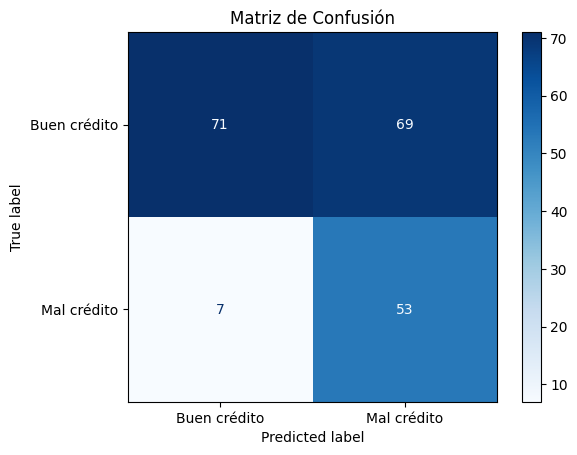

In [71]:
# Creamos matriz de confusión, para visualizar qué tanto se equivoca nuestro modelo
cm = confusion_matrix(y_test, predicciones, labels = [0,1])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=['Buen crédito','Mal crédito'] # Muestra tus etiquetas originales (0:bad y 1:good)
)

disp.plot(cmap=plt.cm.Blues)
plt.title(f"Matriz de Confusión")

### Obtenemos los pesos del modelo. 
Los coeficientes estimados por la regresión logística permiten analizar el peso o el poder de predicción qué posee cada variable, y como cada una influye en la probabilidad final asignada a cada observación con respecto a pertenecer a la clase que nos interesa, en este caso, si la observación representa un riesgo crediticio o no.
Un coeficiente positivo indica que dicha variable aumenta la probabilidad estimada de que el crédito sea riesgoso, mientras que un coeficiente negativo reduce dicha probabilidad.

Tener en cuenta que, debido a la utilización de One-Hot-Encoder, en donde utilizamos valores de referencia para cada variable, dichos coeficientes deben interpretarse respecto de la categoria de referencia definida durante el preprocesamiento.
Ejemplo de interpretación:

- cat__checking_status_<0 (coeficiente = 1.769).
La categoría de referencia para checking_status es no checking. Por lo tanto, manteniendo constantes las demás variables, un cliente con checking_status = <0 presenta una mayor probabilidad de pertenecer a la categoría bad en comparación con un cliente cuya categoría es no checking.

- cat__savings_status_>=1000 (coeficiente = -1.68).
La categoría de referencia para savings_status es <100. En consecuencia, manteniendo constantes las demás variables, un cliente con savings_status ≥1000 presenta una menor probabilidad de pertenecer a la categoría bad en comparación con un cliente con savings_status <100.

In [72]:
nombres_variables = pipeline.named_steps['modelo'].feature_names_in_
coeficientes = pipeline.named_steps['modelo'].coef_[0]

df_coeficientes_modelo = pd.DataFrame({
    'Variable' : nombres_variables,
    'Coeficientes' : coeficientes
}).sort_values(by='Coeficientes', key=abs, ascending = False)

print(df_coeficientes_modelo)

                                             Variable  Coeficientes
1                             cat__checking_status_<0      1.869966
47                                bin__foreign_worker      1.558540
15                              cat__purpose_used car     -1.547834
18                         cat__savings_status_>=1000     -1.512432
0                       cat__checking_status_0<=X<200      1.496951
9                              cat__purpose_education      1.496573
28                       cat__other_parties_guarantor     -1.229226
13                               cat__purpose_repairs      1.227917
2                          cat__checking_status_>=200      1.155178
11                               cat__purpose_new car      1.052131
33                    cat__other_payment_plans_stores      0.921580
32                      cat__other_payment_plans_bank      0.889763
4   cat__credit_history_critical/other existing cr...     -0.888006
19               cat__savings_status_no known sa

### Observar las probabilidades asignadas a cada observación (Probabilidad de que la observación pertenezca a la clase "bad").

In [ ]:
probabilidades = pipeline.predict_proba(X_test)
score = pipeline.decision_function(X_test)
predicciones = pipeline.predict(X_test)


resultado = pd.DataFrame({
    "Clase real": y_test,
    "Probabilidad good": probabilidades[:, 0],
    "Probabilidad bad": probabilidades[:, 1],
    "Clase predicha": predicciones,
    "Score": score
}, index=X_test.index)

resultado.head()

,Clase real,Probabilidad good,Probabilidad bad,Clase predicha,Score
977,0,0.316178,0.683822,1,0.771395
735,0,0.048257,0.951743,1,2.981756
615,0,0.070873,0.929127,1,2.573351
413,0,0.761161,0.238839,0,-1.159057
563,1,0.058484,0.941516,1,2.778737


### Chequeo de multicolinealidad aproximada

1. Si bien el uso de One-Hot Encoding con categorías de referencia elimina la multicolinealidad perfecta entre las variables categóricas, aún podría existir multicolinealidad aproximada, es decir, relaciones lineales fuertes entre variables predictoras. Esto podría incrementar la varianza de los coeficientes, haciéndolos más inestables y dificultando su interpretación, debido a dicha inestabilidad.  

Para evaluar esta situación se calcula el Variance Inflation Factor (VIF) de cada variable predictora. El VIF cuantifica en qué medida una variable puede explicarse mediante una combinación lineal de las restantes variables del modelo. Valores elevados de VIF indican una mayor presencia de multicolinealidad y, en consecuencia, una mayor incertidumbre en la estimación de los coeficientes asociados a dichas variables.

In [ ]:
X_train_trans = pipeline.named_steps['preprocesador'].transform(X_train)

vif = pd.DataFrame({
    "Variable": X_train_trans.columns,
    "VIF": [
        variance_inflation_factor(X_train_trans.values, i)
        for i in range(X_train_trans.shape[1])
    ]
})

vif = vif.sort_values("VIF", ascending=False)

print(vif)

                                             Variable       VIF
47                                bin__foreign_worker  9.928501
30          cat__property_magnitude_no known property  3.560667
34                              cat__housing_for free  3.247548
40                                 num__credit_amount  2.630147
4   cat__credit_history_critical/other existing cr...  2.626667
22                                cat__employment_>=7  2.253845
46                                 bin__own_telephone  2.251297
31                cat__property_magnitude_real estate  2.143586
39                                      num__duration  2.080620
24            cat__personal_status_female div/dep/mar  2.073941
1                             cat__checking_status_<0  1.986970
11                               cat__purpose_new car  1.970686
10                   cat__purpose_furniture/equipment  1.912391
29             cat__property_magnitude_life insurance  1.898566
0                       cat__checking_st

Podemos ver que no hay una gran correlación entre nuestras variables. Aquella que presenta un valor más elevado es una sola, "bin__foreign_worker". Vamos a evaluar con qué variables está relacionada:

In [ ]:
corr = X_train_trans.corr(numeric_only=True)
corr["bin__foreign_worker"].sort_values(
    key=abs,
    ascending=False
).head(15)

bin__foreign_worker                          1.000000
num__duration                                0.124406
cat__purpose_new car                        -0.121391
cat__property_magnitude_real estate         -0.117443
num__installment_commitment                  0.115549
bin__own_telephone                           0.086520
cat__other_parties_guarantor                -0.079118
cat__employment_<1                          -0.072562
cat__employment_>=7                          0.066367
cat__job_unemp/unskilled non res            -0.066263
cat__housing_for free                        0.064360
num__num_dependents                         -0.062769
cat__checking_status_<0                     -0.062402
cat__property_magnitude_no known property    0.058645
num__residence_since                         0.058574
Name: bin__foreign_worker, dtype: float64

2. Evaluaremos el número de condicionamiento de nuestra matriz. El mismo nos ayudará a saber si nuestra matriz podría generar problemas de estabilidad numérica, ya que mientras mayor es el número de condicionamiento, más inestabilidad podrá generar. 

In [ ]:
condition_number = np.linalg.cond(X_train_trans)

print(f"Número de condición: {condition_number:.2f}")

Número de condición: 16.68


### Decisión sobre regularización 
No se han detectado problemas relevantes de multicolinealidad, y nuestra matriz de entrenamiento está bien condicionada, lo que indica que obtendremos coeficientes estables. 
Sin embargo, debido a que nuestro dataset es pequeño, y hay categorias representadas por muy pocos datos, probaremos utilizar la regularización l2, ya que la misma podría mejorar la capacidad de generalización del modelo al reducir el sobreajuste. 
Aplicamos regularización l2 y luego compararemos los resultados obtenidos por ambos modelos. 

              precision    recall  f1-score   support

           0       0.92      0.52      0.67       140
           1       0.45      0.90      0.60        60

    accuracy                           0.64       200
   macro avg       0.69      0.71      0.63       200
weighted avg       0.78      0.64      0.65       200



Text(0.5, 1.0, 'Matriz de Confusión')

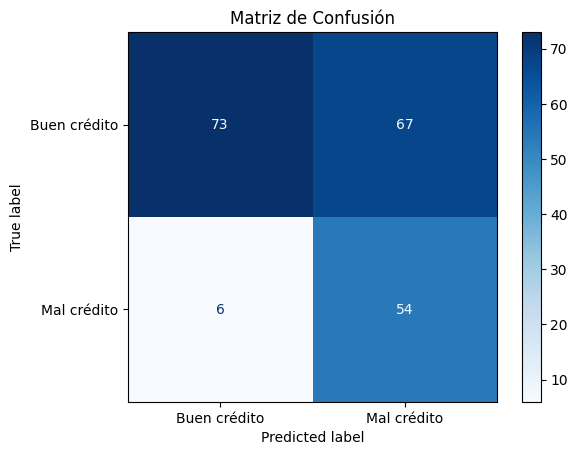

In [ ]:
pipeline2 = Pipeline([
    ('preprocesador', DataPreProcessor(columnas_categoricas,referencias, columnas_numericas,columnas_binarias)),
    ('modelo', LogisticRegression(
    random_state=42,
    penalty = 'l2',
    class_weight=pesos))
])

pipeline2.fit(X_train, y_train)

predicciones2 = pipeline2.predict(X_test)
print(classification_report(y_test,predicciones2))

# Creamos matriz de confusión, para visualizar qué tanto se equivoca nuestro modelo
cm = confusion_matrix(y_test, predicciones2, labels = [0,1])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=['Buen crédito','Mal crédito'] # Muestra tus etiquetas originales (0:bad y 1:good)
)

disp.plot(cmap=plt.cm.Blues)
plt.title(f"Matriz de Confusión")



### Veamos cómo cambiaron nuestros coeficientes

In [ ]:
nombres_variables2 = pipeline2.named_steps['modelo'].feature_names_in_
coeficientes2 = pipeline2.named_steps['modelo'].coef_[0]

df_coeficientes_modelo2 = pd.DataFrame({
    'Variable' : nombres_variables2,
    'Coeficientes' : coeficientes2
}).sort_values(by='Coeficientes', key=abs, ascending = False)

print(df_coeficientes_modelo2)

                                             Variable  Coeficientes
1                             cat__checking_status_<0      1.761696
15                              cat__purpose_used car     -1.439809
0                       cat__checking_status_0<=X<200      1.392372
47                                bin__foreign_worker      1.293971
9                              cat__purpose_education      1.278119
18                         cat__savings_status_>=1000     -1.227077
28                       cat__other_parties_guarantor     -1.095299
2                          cat__checking_status_>=200      1.016738
11                               cat__purpose_new car      0.989424
13                               cat__purpose_repairs      0.966860
4   cat__credit_history_critical/other existing cr...     -0.853617
32                      cat__other_payment_plans_bank      0.831429
33                    cat__other_payment_plans_stores      0.828223
19               cat__savings_status_no known sa

In [ ]:
comparacion = pd.DataFrame({
    "Variable": nombres_variables,
    "Sin regularización": coeficientes,
    "Con L2": coeficientes2
})

comparacion["Diferencia absoluta"] = (
    abs(comparacion["Con L2"] - comparacion["Sin regularización"])
)

comparacion = comparacion.sort_values(
    by="Diferencia absoluta",
    ascending=False
)

print(comparacion)

                                             Variable  Sin regularización  \
18                         cat__savings_status_>=1000           -1.512432   
47                                bin__foreign_worker            1.558540   
13                               cat__purpose_repairs            1.227917   
9                              cat__purpose_education            1.496573   
14                            cat__purpose_retraining           -0.602880   
37                   cat__job_unemp/unskilled non res           -0.302928   
2                          cat__checking_status_>=200            1.155178   
28                       cat__other_parties_guarantor           -1.229226   
8                     cat__purpose_domestic appliance            0.412981   
1                             cat__checking_status_<0            1.869966   
15                              cat__purpose_used car           -1.547834   
0                       cat__checking_status_0<=X<200            1.496951   

Si bien como habiamos analizado anteriormente, nuestra matriz de entrenamiento no presentaba problemas significativos que justificaran la incorporación de una regularización L2 desde el punto de vista de la estabilidad numérica y de nuestros coeficientes, aún así se decidió entrenar un segundo modelo regularizado para poder comprobar la capacidad de predicción del modelo.

La evaluación de las métricas del segundo modelo mostró una mejoría, lo que significa que la capacidad de clasificación y la reducción del error mejoró gracias a la regularización, es decir, logramos obtener un modelo con una mejor capacidad de generalización. 

En consecuencia, se considera al segundo modelo como nuestro modelo final de predicción, debido a su desempeño predictivo. 

### Qué nos dicen las métricas? 
Como se estableció en los objetivos del modelo, clasificar un mal crédito como bueno tiene un costo mucho mayor que clasificar un buen crédito como malo. Por este motivo, el modelo debe priorizar la detección de los clientes riesgosos, incluso si eso implica clasificar como riesgosos a buenos clientes.
Debido a esto, la métrica de mayor interés es el recall (o sensibilidad) de la clase positiva (correspondiente al mal crédito). Dicha métrica responde a la pregunta: de todos los crétidos que eran malos, cuantos fueron correctamente identificados como malos por el modelo? Cuántos de ellos nuestro modelo logró capturar?

El primer modelo (sin regularización) obtuvo un recall de 0.88 para la clase objetivo, mientras que el segundo un valor de 0.90. Si bien la mejora no es muy significativa, indica que el segundo modelo tiene una mejor capacidad de discriminación, y por lo tanto, reduce la cantidad de malos créditos clasificados como buenos.